# Mastering LLM Workflows: Benchmarking, Tools, and Best Practices 

### Introduction

- [Patick](https://www.linkedin.com/in/patrick-callery-30a31a101/) - Working at [Brainpool.ai](https://brainpool.ai/) as a Machine Learning Engineer

- Brainpool.ai has variety of interesting projects on the go working with businesses to adopt AI to help with their business problems. Includes projects:
    * helping architects to chose more environmentally sustainable materials when designing buildings using AI search
    * using CCTV footage to do analytics on electric vehicles on the motorway
    * using AI to help detect market manipulation

- Currently hiring for variety of roles including Machine Learning Engineers, Software Engineers, Technical Project Engineers. [Link](https://brainpool.ai/careers) to careers page. Reach out to [Peter Bebbington](https://ca.linkedin.com/in/bebbington) on LinkedIn or peter@brainpool.ai if interested in learning more about for roles

### Overview of Demo
- Why it is important to evaluate AI systems

- Overview of the dataset being used for the demo

- Brief overview of RAG Pipelines

- Demo RAG Pipeline built using Google's Natural Questions Dataset

- Demo Evaluation Metrics

- Resources and practices found useful

- Questions

### Why Evaluating AI systems is Important

- **Accuracy and Reliability:** Ensures the AI provides correct and trustworthy information, reducing the risk of misinformation.


- **Performance Measurement:** Assesses the efficiency and speed of the system, ensuring it meets required benchmarks.


- **User Experience:** Enhances the interaction quality, making the AI more intuitive and user-friendly.


- **Bias Detection:** Identifies and mitigates biases, promoting fairness and ethical use.


- **Adaptability:** Evaluates how well the system adapts to new data and evolving requirements.


- **Error Identification:** Helps in pinpointing and addressing errors or shortcomings in the AI’s responses.


- **Compliance:** Ensures adherence to regulatory standards and guidelines, maintaining legal and ethical integrity.


- **Continuous Improvement:** Provides insights for ongoing development and refinement of the AI system.

### Demo

#### Google's Natural Questions Dataset

In [1]:
import json
from IPython.display import Image, display
from pydata_manchester_talk.utility import get_long_answer, get_short_answer
from pydata_manchester_talk.config import DataConfig
import pprint


data_config = DataConfig()

[Google's Natural Question Dataset](https://ai.google.com/research/NaturalQuestions) - large-scale corpus designed for training and evaluating open-domain question answering systems.

Contains real user queries from Google Search with detailed annotations for both long and short answers found within Wikipedia articles

The dataset is widely used in AI research to develop models capable of understanding and processing natural language queries.

In [2]:
wiki_docs = []
with open(data_config.natural_questions_training_path, 'r') as file:
    for i, line in enumerate(file):
        wiki_docs.append(json.loads(line))

In [3]:
how_i_met_your_mother_doc = wiki_docs[1]

In [4]:
how_i_met_your_mother_doc.keys()

dict_keys(['document_text', 'long_answer_candidates', 'question_text', 'annotations', 'document_url', 'example_id'])

Document text contains the Wiki doc HTML

In [5]:
how_i_met_your_mother_doc.get("document_text")[0:100]

'The Mother ( How I Met Your Mother ) - wikipedia <H1> The Mother ( How I Met Your Mother ) </H1> Jum'

Question text is the Google Search

In [6]:
how_i_met_your_mother_doc.get("question_text")

'how i.met your mother who is the mother'

Annotations gives the long and short answers for the question if in the text

In [7]:
how_i_met_your_mother_doc.get("annotations")

[{'yes_no_answer': 'NONE',
  'long_answer': {'start_token': 212, 'candidate_index': 15, 'end_token': 310},
  'short_answers': [{'start_token': 213, 'end_token': 215}],
  'annotation_id': 12034874153783787365}]

Have created utility method for getting the text from the annotations

In [8]:
print(get_long_answer(how_i_met_your_mother_doc))

<P> Tracy McConnell , better known as `` The Mother '' , is the title character from the CBS television sitcom How I Met Your Mother . The show , narrated by Future Ted , tells the story of how Ted Mosby met The Mother . Tracy McConnell appears in 8 episodes from `` Lucky Penny '' to `` The Time Travelers '' as an unseen character ; she was first seen fully in `` Something New '' and was promoted to a main character in season 9 . The Mother is played by Cristin Milioti . </P>


In [9]:
print(get_short_answer(how_i_met_your_mother_doc))

['Tracy', 'McConnell']


#### Brief Overview of RAG Pipelines

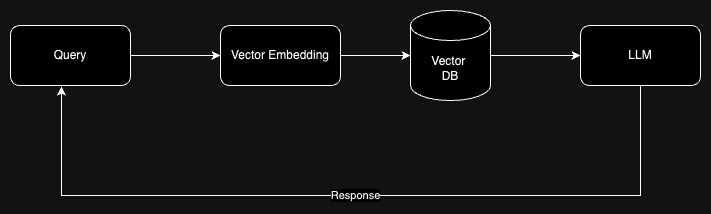

High level overview of RAG Pipeline


In [10]:
display(Image(filename='./images/rag_pipeline_high_level.png',width=1000, height=1000))
print("High level overview of RAG Pipeline")

#### Building a RAG Pipeline Using Haystack

**Haystack** ([link](https://github.com/deepset-ai/haystack) to GitHub):
-  **open-source** framework designed for building search systems that leverage natural language processing (NLP) and machine learning. It facilitates the creation of sophisticated search applications capable of handling unstructured text.

- provides an **end-to-end pipeline** for various search-related tasks, including document retrieval, question answering, and conversational AI. It supports a wide range of data sources, from databases to document stores, and integrates seamlessly with various NLP models and libraries. 

- highly modular and **vendor-agnostic**, allowing developers to use large language models (LLMs) from various providers such as OpenAI, Anthropic, and others. This flexibility ensures adaptability to diverse industry needs and applications while avoiding vendor lock-in.

- Alternative to frameworks like LlamaIndex and LangChain

#### Ingesting the Data Into the Vector DB

In [11]:
from haystack.document_stores.in_memory import InMemoryDocumentStore
from pydata_manchester_talk.pipeline_builder import DataIngestionPipelineBuilder
from haystack import Document
import os

In [12]:
document_store = InMemoryDocumentStore()
data_ingestion_pipeline_builder = DataIngestionPipelineBuilder(document_store=document_store)
data_ingestion_pipeline_builder.build_pipeline()

In [13]:
data_ingestion_pipeline_builder.pipeline.draw(f"{os.getcwd()}/images/ingestion_pipeline.png")

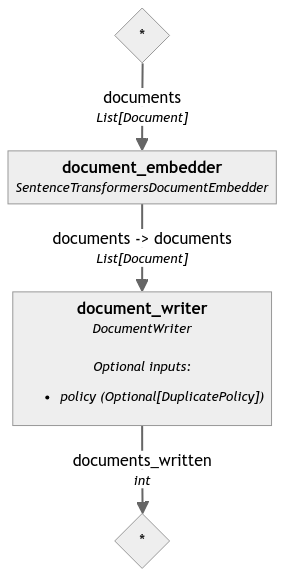

In [14]:
display(Image(filename='./images/ingestion_pipeline.png',width=500, height=500))

In [15]:
docs_for_vector_db = [Document(content=doc["document_text"]) for doc in wiki_docs[0:10]]

In [16]:
data_ingestion_pipeline_builder.run_pipeline(docs_for_vector_db)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Creating the RAG Pipeline

In [18]:
from pydata_manchester_talk.pipeline_builder import RagPipelineBuilder
from pydata_manchester_talk.config import RagConfig

In [19]:
rag_config = RagConfig()

In [20]:
with open(rag_config.prompt_template_path, 'r') as file:
    prompt_template = file.read()

In [22]:
rag_pipeline_builder = RagPipelineBuilder(document_store=document_store, prompt_template=prompt_template)
rag_pipeline_builder.build_pipeline()

In [23]:
pipeline = rag_pipeline_builder.get_pipeline()

In [24]:
pipeline.draw(f"{os.getcwd()}/images/rag_pipeline.png")

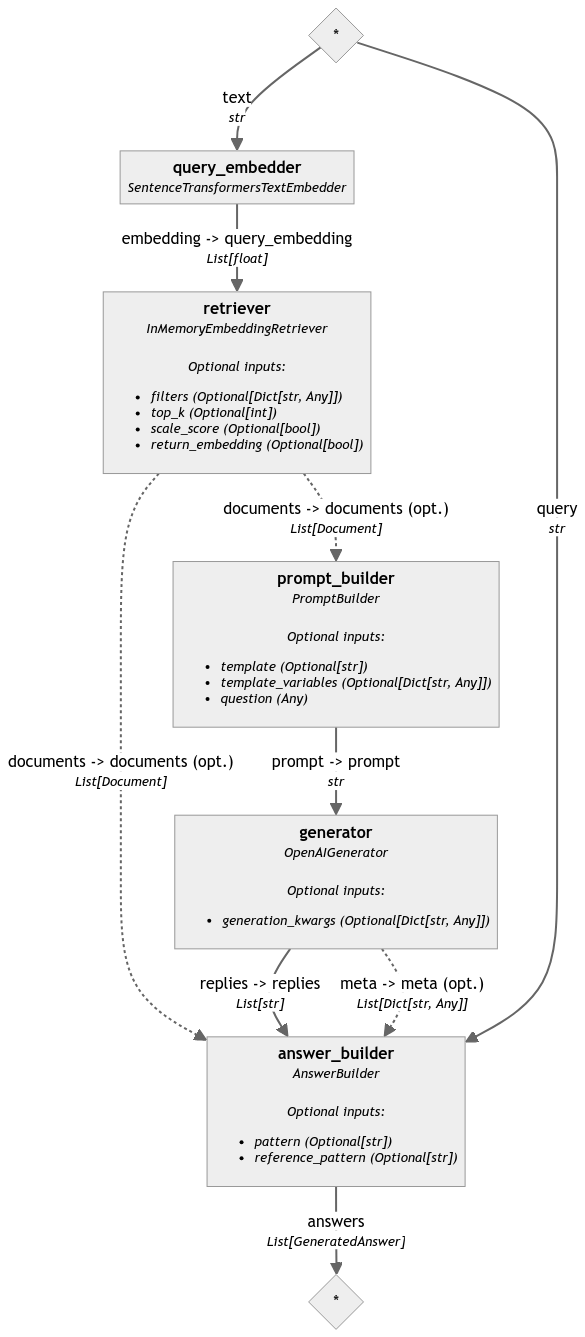

In [25]:
display(Image(filename='./images/rag_pipeline.png',width=500, height=500))

In [26]:
rag_pipeline_builder.run_pipeline("Who is ted's best friend?")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


BadRequestError: Error code: 400 - {'error': {'message': "This model's maximum context length is 16385 tokens. However, your messages resulted in 17881 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}

Introducing chunking

In [28]:
data_ingestion_pipeline_builder.add_preprocessor_to_pipeline()

In [29]:
data_ingestion_pipeline_builder.pipeline.draw(f"{os.getcwd()}/images/ingestion_pipeline.png")

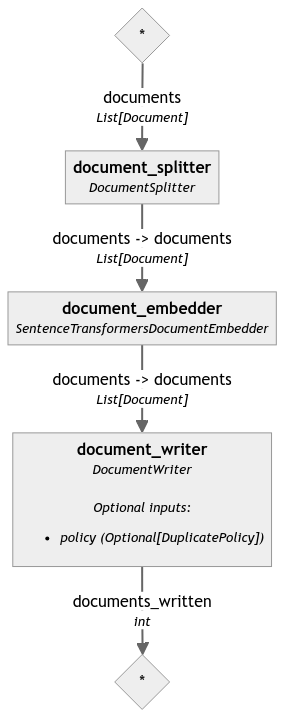

In [30]:
display(Image(filename='./images/ingestion_pipeline.png',width=500, height=500))

In [31]:
document_store.delete_documents(document_ids=[doc.id for doc in docs_for_vector_db])

In [32]:
data_ingestion_pipeline_builder.run_pipeline_with_chunking(docs_for_vector_db)

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [32]:
pprint.pprint(rag_pipeline_builder.run_pipeline("Who is ted's best friend?"))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

{'answer_builder': {'answers': [GeneratedAnswer(data='Barney, Lily, Marshall, '
                                                     'and Robin.',
                                                query="Who is ted's best "
                                                      'friend?',
                                                documents=[Document(id=93a2d8110781f047ef41e8884374f8df3a6944601167928921b71d71c00a3e41, content: 'it behind in her apartment . Ted and The Mother meet at the Farhampton train station following Barne...', meta: {'source_id': '8be432ed442ad6ffb9c7a18d4d36b8fe120321a4e8e566175e948183fe2a8daf', 'page_number': 1, 'split_id': 1, 'split_idx_start': 1893, '_split_overlap': [{'doc_id': '31a4b78c65c6d318b839834c66e4ab73bc26ebc52848a62491474b85ec096b4c', 'range': (1892, 2637)}, {'doc_id': '4a18264113c4200e934336f6f633732913d66dec9dadb1bba22e4a8f5eb6caed', 'range': (0, 740)}]}, score: 0.5240840540932556),
                                                           Docu

#### Evaluating Metrics

A RAG pipeline can be split into two key components of retrieval and generation => can evaluate the performance of the retrieval, generation and overall pipeline separately

[TruEra](https://truera.com/) has created a useful learning construct of a [RAG triad](https://www.trulens.org/trulens_eval/getting_started/core_concepts/rag_triad/) for thinking about how to measure the performance of different aspects of the RAG pipeline 

Haystack has introduced inbuilt evaluation functionality including the ability to create `EvaluationPipelines` with a [variety of out of the box evaluators](https://docs.haystack.deepset.ai/docs/evaluators) including integrations with [deepeval](https://github.com/confident-ai/deepeval) and [ragas](https://github.com/explodinggradients/ragas)

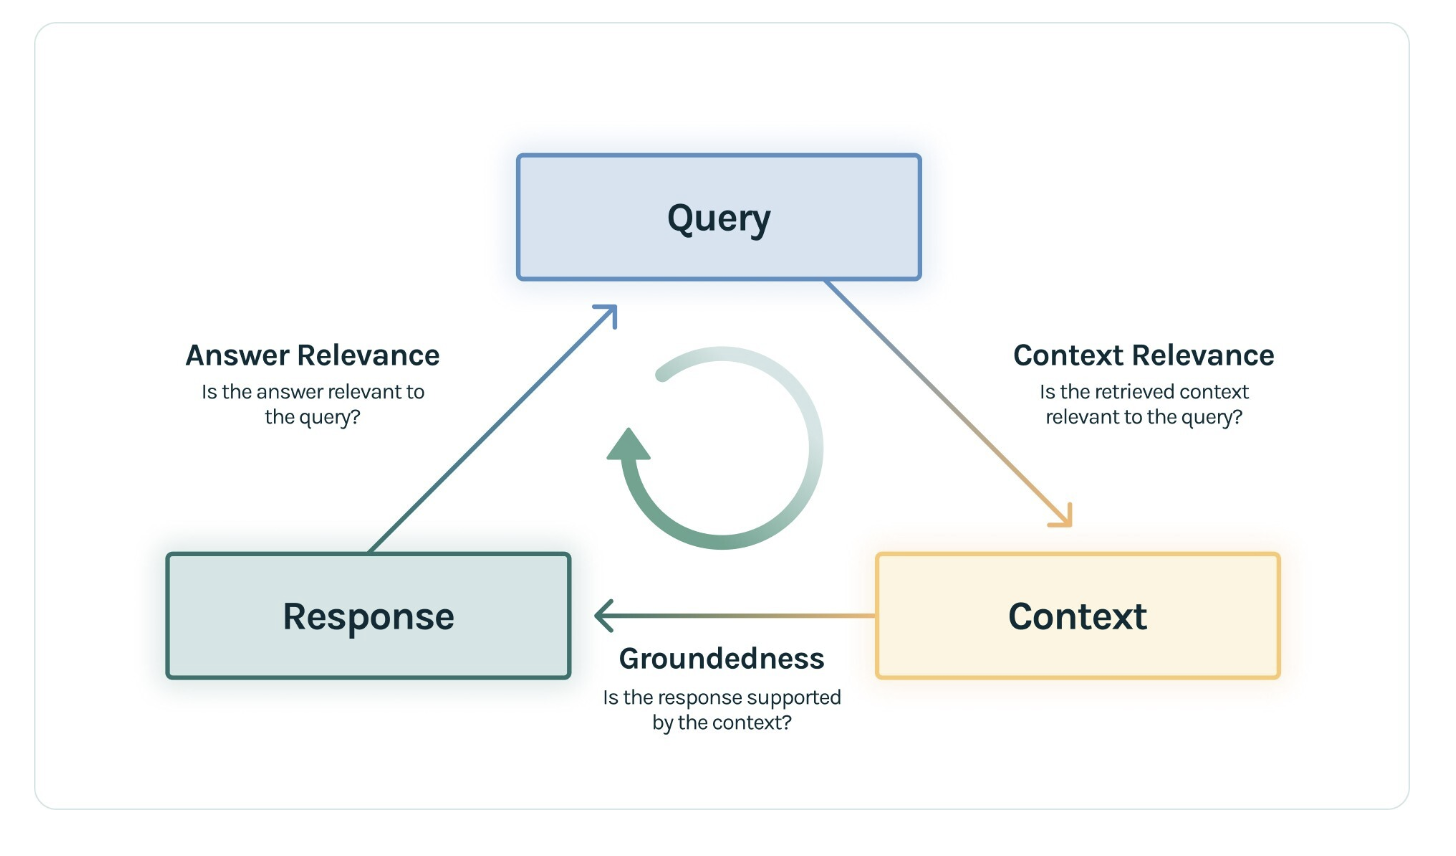

RAG Triad from TruLens: https://www.trulens.org/trulens_eval/getting_started/core_concepts/rag_triad/


In [82]:
display(Image(filename='./images/rag_triad.png',width=1000, height=1000))
print("RAG Triad from TruLens: https://www.trulens.org/trulens_eval/getting_started/core_concepts/rag_triad/")

To start with we're going to look at using 
- **document mean reciprocal rank** to measure the rank ground truth labels appear in the list of retrieved docs. This will help give an indication of performance of the document search

- **faithfulness** to evaluate whether the generated answer can be inferred from the provided contexts/documents using an LLM. Useful for checking whether the answer is coming from the search component of the RAG or the LLM is getting it from the data it was trained on

#### Evaluating the Pipeline

In [33]:
from pydata_manchester_talk.utility import get_ground_truth_chunks

In [34]:
ground_truth_chunks = get_ground_truth_chunks(wiki_docs[0:10], document_splitter=data_ingestion_pipeline_builder.get_document_splitter())

In [35]:
for doc_index in range(0,10):
    wiki_docs[doc_index]["ground_truth_chunks"] = ground_truth_chunks[doc_index]

In [36]:
ground_truth_docs = [{"document_text": doc.get("document_text"), "question_text" : doc.get("question_text"), "answer": get_long_answer(doc), "ground_truth_chunks": doc.get("ground_truth_chunks")} for doc in wiki_docs[0:10]]

In [37]:
ground_truth_answers = [d.get("answer") for d in ground_truth_docs]

In [38]:
rag_answers = []
retrieved_docs = []
questions = [doc.get("question_text") for doc in ground_truth_docs]

for question in list(questions):
    response = rag_pipeline_builder.pipeline.run(
        {
            "query_embedder": {"text": question},
            "prompt_builder": {"question": question},
            "answer_builder": {"query": question},
        }
    )
    print(f"Question: {question}")
    print("Answer from pipeline:")
    print(response["answer_builder"]["answers"][0].data)
    print("\n-----------------------------------\n")

    rag_answers.append(response["answer_builder"]["answers"][0].data)
    retrieved_docs.append(response["answer_builder"]["answers"][0].documents)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Question: which is the most common use of opt-in e-mail marketing
Answer from pipeline:
The most common use of opt-in email marketing is to send newsletters to a company's customers informing them of upcoming events, promotions, or new products.

-----------------------------------



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Question: how i.met your mother who is the mother
Answer from pipeline:
The mother in the TV show "How I Met Your Mother" is Tracy McConnell, also known as "The Mother."

-----------------------------------



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Question: who did the voice of the magician in frosty the snowman
Answer from pipeline:
Billy De Wolfe

-----------------------------------



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Question: what indian tribe did the acadians form friendships and alliances with
Answer from pipeline:
The Acadians formed friendships and alliances with the Mi'kmaq tribe.

-----------------------------------



Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Question: what is considered the outer banks in north carolina
Answer from pipeline:
The Outer Banks in North Carolina is considered a 200-mile-long string of barrier islands and spits off the coast of North Carolina and southeastern Virginia, separating the Currituck Sound, Albemarle Sound, and Pamlico Sound from the Atlantic Ocean.

-----------------------------------



In [39]:
from pydata_manchester_talk.pipeline_builder import EvaluationPipeline

In [40]:
evaluation_pipeline = EvaluationPipeline()
evzaluation_pipeline = evaluation_pipeline.build_pipeline()

In [41]:
results = evaluation_pipeline.run_pipeline(questions, retrieved_docs, ground_truth_docs, rag_answers)

100%|██████████| 10/10 [00:11<00:00,  1.14s/it]


In [42]:
from haystack.evaluation.eval_run_result import EvaluationRunResult

In [43]:
inputs = {
    "question": list(questions),
    "contexts": list([d.content] for d in docs_for_vector_db),
    "answer": list(ground_truth_answers),
    "predicted_answer": rag_answers,
}

evaluation_result = EvaluationRunResult(run_name="natural_qa_rag_pipeline", inputs=inputs, results=results)
evaluation_result.score_report()

,metrics,score
0,doc_mrr_evaluator,0.233333
1,faithfulness,0.700000


### Giving deepeval integration a go!

In [44]:
from haystack_integrations.components.evaluators.deepeval import DeepEvalEvaluator, DeepEvalMetric

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/patrickcallery/dev/pydata-manchester-talk/.venv/lib/python3.12/site-packages/deepeval/__init__.py:39: UserWarning: You are using deepeval version 0.20.57, however version 0.21.73 is available. You should consider upgrading via the "pip install --upgrade deepeval" command.
  warnings.warn(


Note that requires data in slightly different format, so some massaging required to get it into the expected format

In [45]:
contexts = list(d.get("ground_truth_chunks") for d in ground_truth_docs)
contexts_as_list = []
for high_level_doc in contexts:
    context_for_high_level_doc = []
    for chunk in high_level_doc:
        context_for_high_level_doc.append(chunk.content)
    contexts_as_list.append(context_for_high_level_doc)

In [46]:
answer_relevancy_evaluator = DeepEvalEvaluator(
    metric=DeepEvalMetric.ANSWER_RELEVANCY,
    metric_params={"model": "gpt-3.5-turbo"},
)

In [47]:
evaluation_pipeline.pipeline.add_component("answer_relevancy_evaluator", answer_relevancy_evaluator)

In [48]:
results = evaluation_pipeline.pipeline.run(
    {
        "doc_mrr_evaluator": {
            "ground_truth_documents": list(d.get("ground_truth_chunks") for d in ground_truth_docs),
            "retrieved_documents": retrieved_docs,
        },
        "faithfulness": {
            "questions": list(questions),
            "contexts": list(d.get("ground_truth_chunks") for d in ground_truth_docs),
            "predicted_answers": rag_answers,
        },
        "answer_relevancy_evaluator" : {
            "questions": list(questions),
            "contexts": contexts_as_list,
            "responses": rag_answers
        }
    }
)

100%|██████████| 10/10 [00:11<00:00,  1.16s/it]

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

In [49]:
results.get("answer_relevancy_evaluator")

{'results': [[{'name': 'answer_relevancy',
    'score': 0.8,
    'explanation': 'The score is 0.80 because the original answer effectively addresses the most common use of opt-in email marketing, which is sending newsletters to inform customers of events, promotions, or products. However, the mention of legal requirements in different countries is irrelevant to the question and lowers the relevancy score.'}],
  [{'name': 'answer_relevancy',
    'score': 0.8,
    'explanation': 'The score is 0.80 because the answer correctly identifies Tracy McConnell as the mother in "How I Met Your Mother" but includes an irrelevant detail about her being the title character. This lowers the score slightly as it doesn\'t directly address the question.'}],
  [{'name': 'answer_relevancy',
    'score': 1.0,
    'explanation': 'The score is 1.00 because the answer directly addresses the original question by stating that internal fertilization takes place in humans. There are no irrelevant points present i

### Trying Out TruLens

Following Truelens quickstart [guide](https://github.com/truera/trulens#quick-usage) with some adjustments for the Haystack RAG

In [63]:
from trulens_eval import Feedback, Select
from trulens_eval.feedback.provider.openai import OpenAI

import numpy as np

provider = OpenAI(model_engine="gpt-4o")

# Define a groundedness feedback function
f_groundedness = (
    Feedback(provider.groundedness_measure_with_cot_reasons, name = "Groundedness")
    .on(Select.RecordCalls.retrieve.rets.collect())
    .on_output()
)
# Question/answer relevance between overall question and answer.
f_answer_relevance = (
    Feedback(provider.relevance_with_cot_reasons, name = "Answer Relevance")
    .on_input()
    .on_output()
)

# Context relevance between question and each context chunk.
f_context_relevance = (
    Feedback(provider.context_relevance_with_cot_reasons, name = "Context Relevance")
    .on_input()
    .on(Select.RecordCalls.retrieve.rets[:])
    .aggregate(np.mean) # choose a different aggregation method if you wish
)

✅ In Groundedness, input source will be set to __record__.app.retrieve.rets.collect() .
✅ In Groundedness, input statement will be set to __record__.main_output or `Select.RecordOutput` .
✅ In Answer Relevance, input prompt will be set to __record__.main_input or `Select.RecordInput` .
✅ In Answer Relevance, input response will be set to __record__.main_output or `Select.RecordOutput` .
✅ In Context Relevance, input question will be set to __record__.main_input or `Select.RecordInput` .
✅ In Context Relevance, input context will be set to __record__.app.retrieve.rets[:] .


In [21]:
from pydata_manchester_talk.rag_trulens import RagTrulens

In [76]:
rag_trulens = RagTrulens(document_store=document_store, prompt_template=prompt_template)

In [59]:
print(prompt_template)

You have to answer the following question based on the given context information only.

Context:
{% for document in documents %}
    {{ document.content }}
{% endfor %}

Question: {{question}}
Answer:



In [60]:
rag_trulens = RagTrulens(document_store=document_store, prompt_template=prompt_template)

In [73]:
rag_trulens.query("Who is ted's best friend?")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

EMBEDDED_QUERY
[-0.11304401606321335, -0.014320861548185349, 0.027826348319649696, -0.016200203448534012, 0.03860285505652428, 0.03543037176132202, 0.052685048431158066, 0.05230201035737991, -0.03653758391737938, 0.03222917392849922, -0.017823070287704468, 0.056357961148023605, -0.020093010738492012, -0.02431063912808895, -0.03636103495955467, 0.05671972781419754, 0.008394213393330574, 0.019648464396595955, 0.026818396523594856, -0.03557724505662918, -0.013166122138500214, -0.013057618401944637, 0.03432615473866463, -0.010186674073338509, 0.044130537658929825, 0.043744929134845734, 0.04997822269797325, -0.04463541880249977, -0.0051711685955524445, 0.019009549170732498, 0.02490595541894436, -0.06328491866588593, -0.02811788208782673, 0.060508158057928085, 0.0047323391772806644, 0.039078906178474426, 0.03270620107650757, 0.00326094264164567, 0.10136420279741287, 0.03329853713512421, -0.03901979699730873, -0.037728775292634964, -0.009272315539419651, 0.026121711358428, -0.1264546811580658

{'replies': ['Barney, Lily, Marshall, and Robin'],
 'meta': [{'model': 'gpt-3.5-turbo-0125',
   'index': 0,
   'finish_reason': 'stop',
   'usage': {'completion_tokens': 9,
    'prompt_tokens': 1797,
    'total_tokens': 1806}}]}

In [69]:
from trulens_eval import Tru
from trulens_eval.tru_custom_app import instrument
tru = Tru()
tru.reset_database()

In [70]:
from trulens_eval import TruCustomApp
tru_rag = TruCustomApp(rag_trulens,
    app_id = 'RAG v1',
    feedbacks = [f_groundedness, f_answer_relevance, f_context_relevance])

In [74]:
with tru_rag as recording:
    rag_trulens.query("Who is Ted's best friend?")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

EMBEDDED_QUERY
[-0.11304401606321335, -0.014320861548185349, 0.027826348319649696, -0.016200203448534012, 0.03860285505652428, 0.03543037176132202, 0.052685048431158066, 0.05230201035737991, -0.03653758391737938, 0.03222917392849922, -0.017823070287704468, 0.056357961148023605, -0.020093010738492012, -0.02431063912808895, -0.03636103495955467, 0.05671972781419754, 0.008394213393330574, 0.019648464396595955, 0.026818396523594856, -0.03557724505662918, -0.013166122138500214, -0.013057618401944637, 0.03432615473866463, -0.010186674073338509, 0.044130537658929825, 0.043744929134845734, 0.04997822269797325, -0.04463541880249977, -0.0051711685955524445, 0.019009549170732498, 0.02490595541894436, -0.06328491866588593, -0.02811788208782673, 0.060508158057928085, 0.0047323391772806644, 0.039078906178474426, 0.03270620107650757, 0.00326094264164567, 0.10136420279741287, 0.03329853713512421, -0.03901979699730873, -0.037728775292634964, -0.009272315539419651, 0.026121711358428, -0.1264546811580658

In [75]:
tru.get_leaderboard()

,Groundedness,Context Relevance,Answer Relevance,latency,total_cost
app_id,,,,,
RAG v1,1.0,0.1,0.3,1.0,0.002723


In [77]:
last_record = recording.records[-1]

from trulens_eval.utils.display import get_feedback_result
get_feedback_result(last_record, "Context Relevance")

,question,context,ret
0,Who is Ted's best friend?,{'id': '93a2d8110781f047ef41e8884374f8df3a6944...,0.0
1,Who is Ted's best friend?,{'id': '9e3a54eb17cee9972e84ff11d9eee2aea44e18...,0.3
2,Who is Ted's best friend?,{'id': '8566af57c33447f91df9512f8fbbcde8f42aa0...,0.0


In [78]:
tru.run_dashboard(port=3453, force=True)

Force stopping dashboard ...
Starting dashboard ...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Accordion(children=(VBox(children=(VBox(children=(Label(value='STDOUT'), Output())), VBox(children=(Label(valu…

Dashboard started at http://192.168.1.124:3453 .


<Popen: returncode: None args: ['streamlit', 'run', '--server.headless=True'...>

#### Iterating

### Resources

- Haystack tutorials on [Benchmarking Haystack Pipelines](https://haystack.deepset.ai/blog/benchmarking-haystack-pipelines) and [Evaluating RAG Pipelines](https://haystack.deepset.ai/tutorials/35_evaluating_rag_pipelines)

- TruLens RAG Triad [Docs](https://www.trulens.org/trulens_eval/getting_started/core_concepts/rag_triad/)

- https://www.deeplearning.ai/ generally very good with lots of free courses on AI tooling. In particular, related to this course: [Building and Evaluating Advanced RAG Applications](https://www.deeplearning.ai/short-courses/building-evaluating-advanced-rag/)

- Nice [repo](https://github.com/Azure-Samples/container-apps-openai) for deploying AI applications into Azure

### Useful Practices

- Start small and get something working. Can sometimes be overwhelming when starting a project using LLMs for a variety of reasons like which model to choose, getting hold of the data and into a usable state. Personally found it useful to get something working E2E (skeleton pipeline) and iterate on it. If working with stakeholders, getting something working in their hands encourages engagement and helps steer the project in the right direction. Building up acceptance tests at different iterations of the pipeline can be useful for this

- Normally quite a lot of glue code when building these types of systems. Important to try to apply some software development best practices like investing in making sure a high level of internal code quality through things like unit testing and linting, CI


## Questions

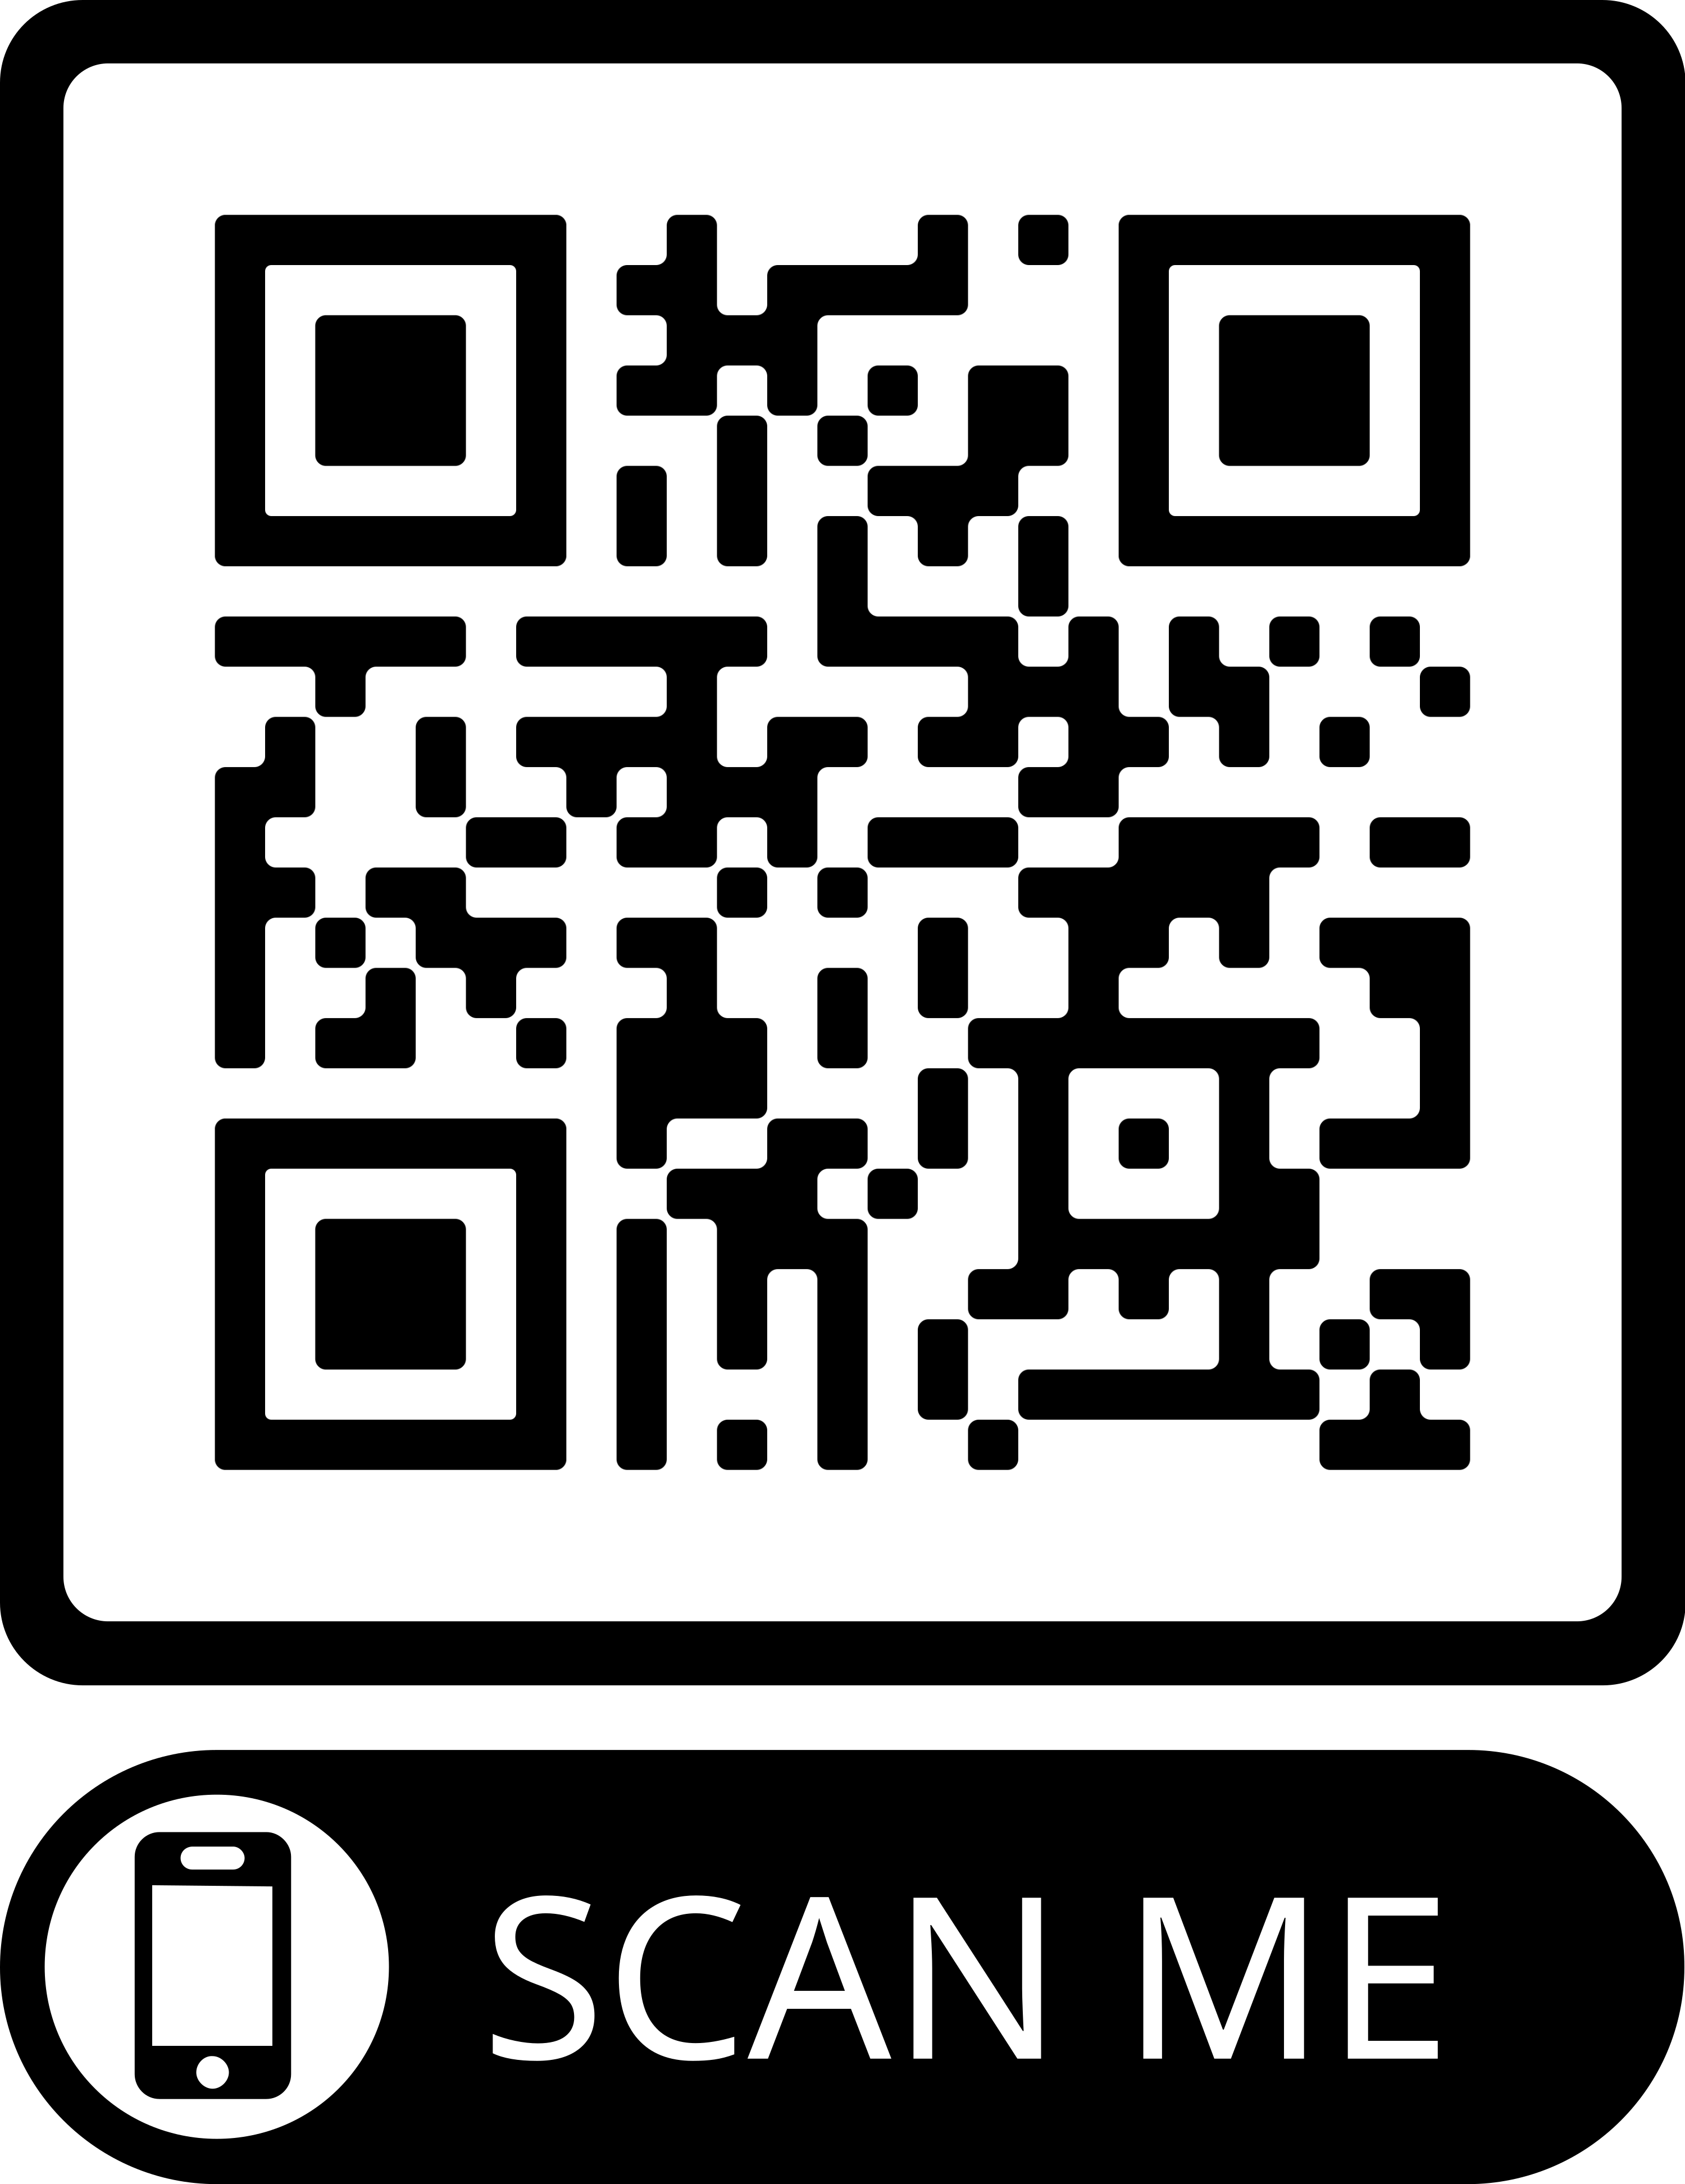

Scan the QR code to access the repository


In [7]:
display(Image(filename='./images/qr_code_to_repo.png',width=300, height=200))
print("Scan the QR code to access the repository")